# Exercises

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn import svm
import numpy as np
import pickle
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})




### Exercise 1
---
Use the sklearn `make_blobs()` function, in the same way that we used in the lesson, to generate a *non linearly separable* dataset with 2 features.  
Fit a linear SVM to the dataset many times, varying the slack hyperparameter $C$, and calculate the model performance in classifying the data.  
What is, approximately, a the best value of the $C$ hyperparameter for this dataset?

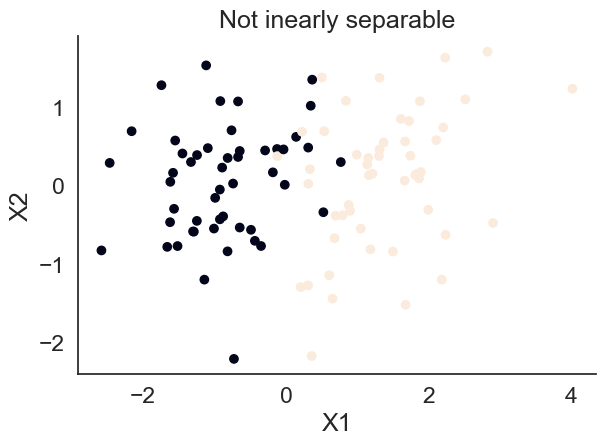

In [50]:
X_nsep,y_nsep = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=0.8)
# plt.figure(figsize=(10,5))
plt.title('Not inearly separable')
plt.xlabel('X1')
plt.ylabel('X2')
plt.scatter(X_nsep[:,0],X_nsep[:,1],c=y_nsep)
plt.tight_layout()

Best C: 2.03
Best accuracy: 0.9400000000000001


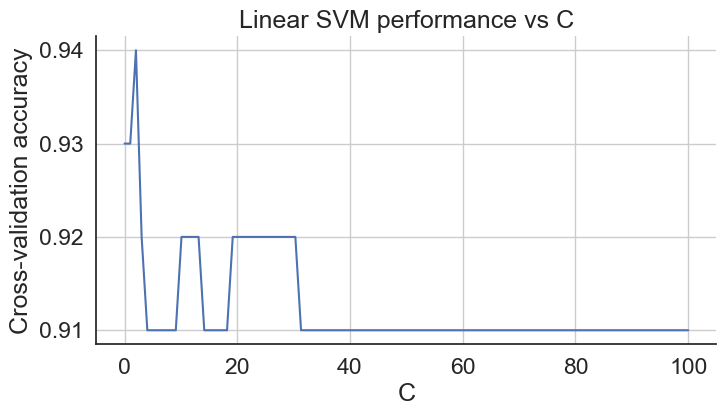

In [51]:
Cs = np.linspace(0.01,100,100)
mean_scores = []
for C in Cs: 
    X,y = X_nsep,y_nsep
    svc_model = svm.SVC(kernel='linear',C=C);
    svc_model.fit(X, y)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(svc_model, X, y, cv=cv)
    mean_scores.append(scores.mean())

# Best C
best_index = np.argmax(mean_scores)
best_C = Cs[best_index]

print("Best C:", best_C)
print("Best accuracy:", mean_scores[best_index])

# Plot
plt.figure(figsize=(8,4))
plt.plot(Cs, mean_scores)
plt.xlabel("C")
plt.ylabel("Cross-validation accuracy")
plt.title("Linear SVM performance vs C")
plt.grid(True)
plt.show()

The smallest value of C for which performance is optimized is 2.03. The smallest value should be chosen as the optimal value for C as it results in a model that is least likely to be subject to overfitting.

### Exercise 2
---
Repeat exercise 1, but using a non-linear SVM model (the sklearn class `SVC` uses [Radial Basis Functions](https://en.wikipedia.org/wiki/Radial_basis_function) as a default, check its documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)). 
To have a fairer assessment of the performance, train the model on a fraction (e.g. 80%) of the data, and test it on the other 20%.
Compare the performance of a linear SVC and a RBF SVC for dataset that are increaslingly non-linearly-separable.


Best C: 0.01
Best accuracy: 0.93


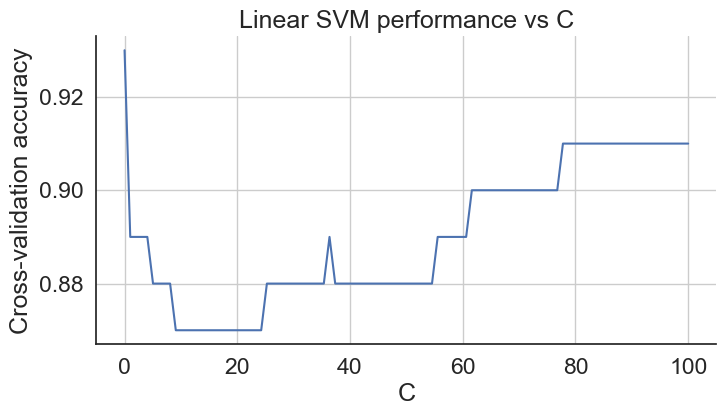

In [53]:
Cs = np.linspace(0.01,100,100)
mean_scores = []
for C in Cs: 
    X,y = X_nsep,y_nsep
    svc_model = svm.SVC(kernel='rbf',C=C);
    svc_model.fit(X, y)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(svc_model, X, y, cv=cv)
    mean_scores.append(scores.mean())

# Best C
best_index = np.argmax(mean_scores)
best_C = Cs[best_index]

print("Best C:", best_C)
print("Best accuracy:", mean_scores[best_index])

# Plot
plt.figure(figsize=(8,4))
plt.plot(Cs, mean_scores)
plt.xlabel("C")
plt.ylabel("Cross-validation accuracy")
plt.title("Linear SVM performance vs C")
plt.grid(True)
plt.show()

Altough a smaller value of C immediately results in the greatest performance, highest accuracy is slightly lower than for the linear classifier. Eventually however it is expected that as C rises beyond 100 even greater accuracy than 0.94 can be reached since the hyperplane can be non-linear and should therefore be able to find some hyperplane that separates the data perfectly. This is also reflected in the performance asymptoting around C=30 for the linear classifier whereas it keeps rising beyond the scale of the plot for the non-linear classifier

Now using a 80/20% split

Best C: 0.01
Test accuracy: 0.9


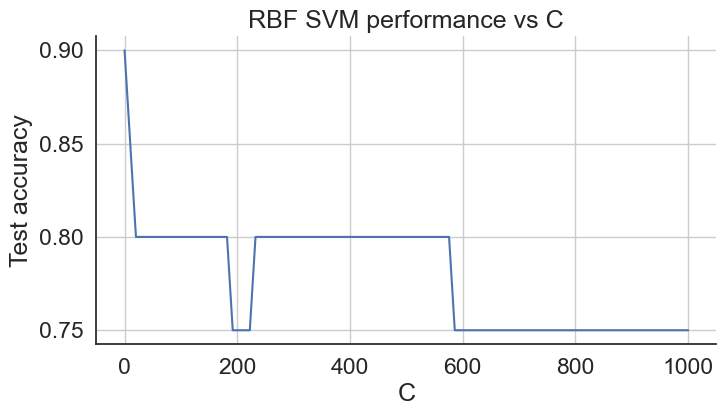

In [ ]:
from sklearn.model_selection import train_test_split

# Split once into training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X_nsep,
    y_nsep,
    test_size=0.2,
    stratify=y_nsep,
    random_state=42
)

Cs = np.linspace(0.01, 1000, 100)
test_scores = []

for C in Cs:
    svc_model = svm.SVC(kernel='rbf', C=C)
    svc_model.fit(X_train, y_train)
    test_scores.append(svc_model.score(X_test, y_test))

# Best C
best_index = np.argmax(test_scores)
best_C = Cs[best_index]

print("Best C:", best_C)
print("Test accuracy:", test_scores[best_index])

# Plot
plt.figure(figsize=(8,4))
plt.plot(Cs, test_scores)
plt.xlabel("C")
plt.ylabel("Test accuracy")
plt.title("RBF SVM performance vs C")
plt.grid(True)
plt.show()

Best C is once again found for C=0.01 right away, altough performance has worsened


L1 (std=0.1)
Linear: Best C = 0.01, Accuracy = 1.000
RBF:    Best C = 0.01, Accuracy = 1.000

L2 (std=1.0)
Linear: Best C = 0.01, Accuracy = 0.900
RBF:    Best C = 0.01, Accuracy = 0.900

L3 (std=10.0)
Linear: Best C = 0.01, Accuracy = 0.650
RBF:    Best C = 0.01, Accuracy = 0.500


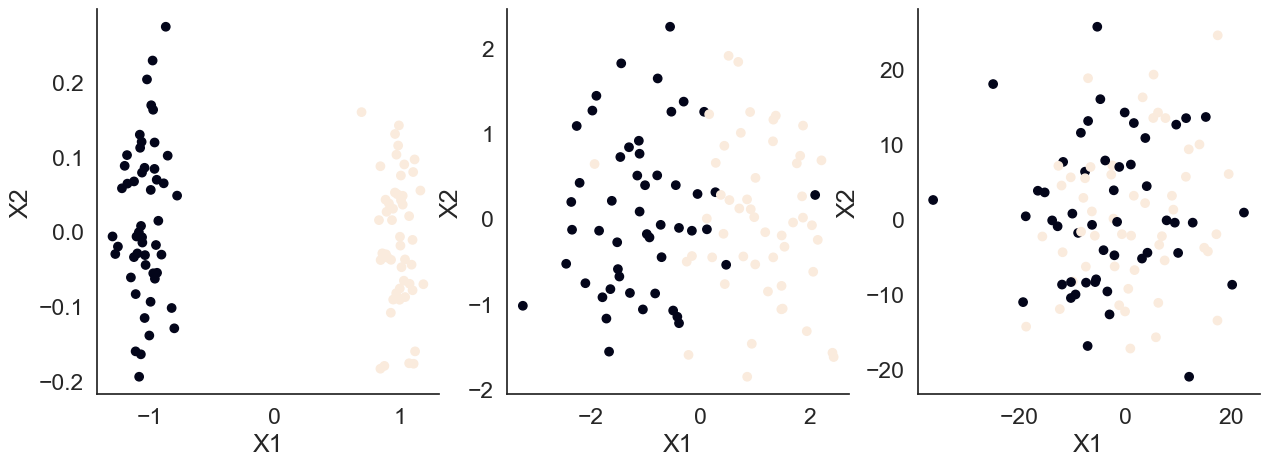

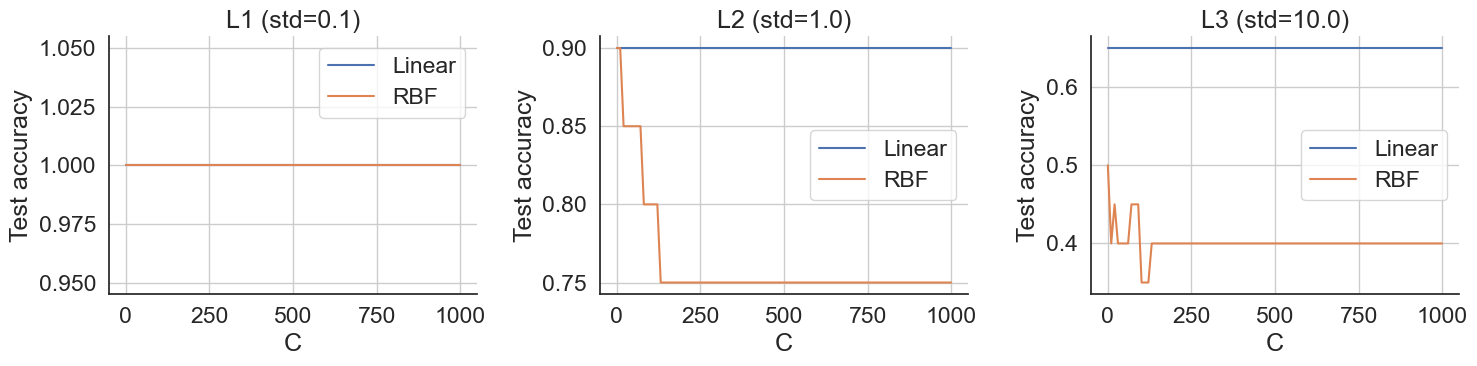

In [66]:
X_nsep_L1,y_nsep_L1 = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=0.1)
X_nsep_L2,y_nsep_L2 = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=1.)
X_nsep_L3,y_nsep_L3 = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=10.)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.scatter(X_nsep_L1[:,0],X_nsep_L1[:,1],c=y_nsep_L1)
plt.subplot(1,3,2)
plt.xlabel('X1')
plt.ylabel('X2')
plt.scatter(X_nsep_L2[:,0],X_nsep_L2[:,1],c=y_nsep_L2)
plt.subplot(1,3,3)
plt.xlabel('X1')
plt.ylabel('X2')
plt.scatter(X_nsep_L3[:,0],X_nsep_L3[:,1],c=y_nsep_L3)

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

datasets = {
    "L1 (std=0.1)": (X_nsep_L1, y_nsep_L1),
    "L2 (std=1.0)": (X_nsep_L2, y_nsep_L2),
    "L3 (std=10.0)": (X_nsep_L3, y_nsep_L3)
}

Cs = np.linspace(0.01, 1000, 100)

plt.figure(figsize=(15,4))

for i, (name, (X, y)) in enumerate(datasets.items(), start=1):

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    linear_scores = []
    rbf_scores = []

    for C in Cs:

        # Linear SVM
        linear = SVC(kernel='linear', C=C)
        linear.fit(X_train, y_train)
        linear_scores.append(linear.score(X_test, y_test))

        # RBF SVM
        rbf = SVC(kernel='rbf', C=C)
        rbf.fit(X_train, y_train)
        rbf_scores.append(rbf.score(X_test, y_test))

    # Best values
    best_lin = np.argmax(linear_scores)
    best_rbf = np.argmax(rbf_scores)

    print(f"\n{name}")
    print(f"Linear: Best C = {Cs[best_lin]:.2f}, Accuracy = {linear_scores[best_lin]:.3f}")
    print(f"RBF:    Best C = {Cs[best_rbf]:.2f}, Accuracy = {rbf_scores[best_rbf]:.3f}")

    # Plot
    plt.subplot(1,3,i)
    plt.plot(Cs, linear_scores, label="Linear")
    plt.plot(Cs, rbf_scores, label="RBF")
    plt.title(name)
    plt.xlabel("C")
    plt.ylabel("Test accuracy")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

surprisingly, the non-linear classifier doesn't achieve greater testing accuracies for the most non-linear dataset and also remains on par with the RBF as data becomes increasingly non-linear (at std=1.0)

### Exercise 3
---
Use the code below to simulate new data.
Generate data and then decode the stimulus identity, see how the decoding performance change when you change the following:

- The amplitude of the noise in the firing rate
- The amplitude of the stimulus modulation of the firing rate
- The number of neurons

Plot and comment.

## Useful code
---


In [131]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import StratifiedKFold
from sklearn import svm
from sklearn.preprocessing import StandardScaler

Now assessing decoding performance for noise level 0
Now assessing decoding performance for noise level 1
Now assessing decoding performance for noise level 10
Now assessing decoding performance for noise level 100
Now assessing decoding performance for noise level 1000


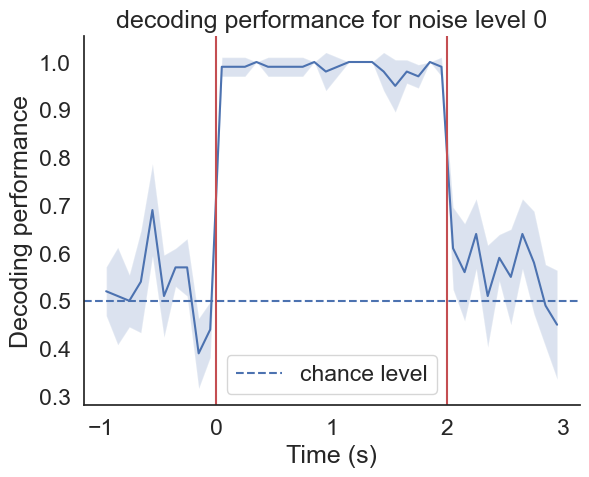

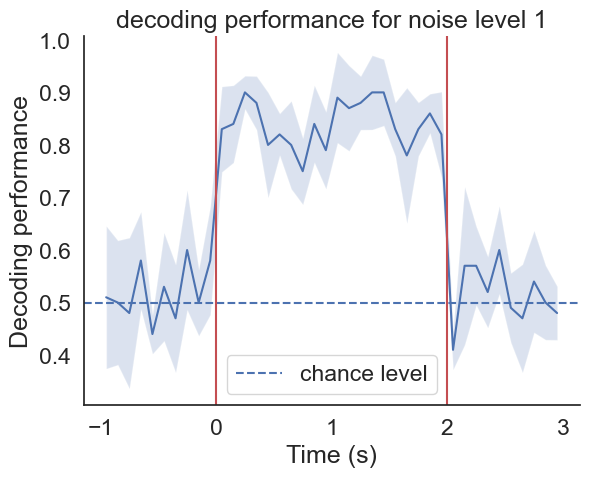

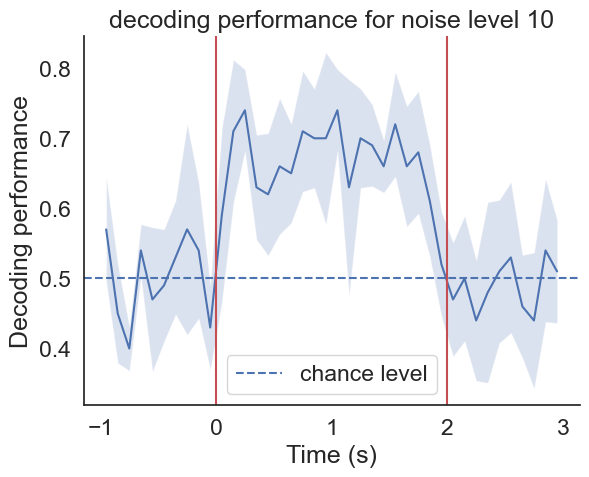

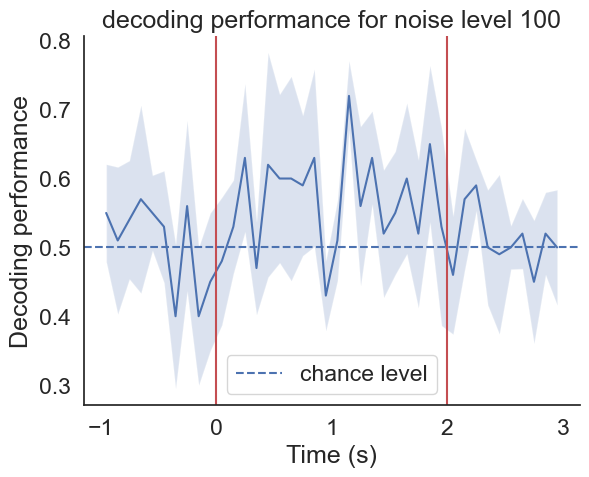

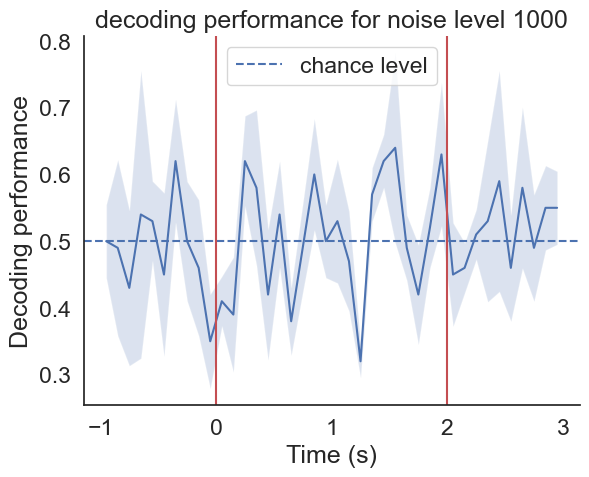

In [135]:
noises = [0,1,10,100,1000]

for noise in noises:
    print(f"Now assessing decoding performance for noise level {noise}")
    n_cells = 20; # number of cells to simulate
    n_stim_type = 2; # number of different stimuli
    sigma_stim = 0.5 # amplitude of stimulus related modulation
    average_firing_rate = 5; # average firing rate across the population

    # generate baseline rates from exponential distirbution
    cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

    # create stimulus average responses, perturbing the population firng rate profile
    # we use a multiplicative modulation in opposite directions for the two stimuli
    modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
    cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
    # sets negative firng rate to 0
    cell_rate_stim[1][cell_rate_stim[1]<0]=0
    cell_rate_stim[2][cell_rate_stim[2]<0]=0

    # simulate spiking activity

    s_rate = 10000 # the sampling rate of our emulated recording system
    noise_rate = noise # we are going to add some spike noise non related to the task
    n_stim = 100 # number of stimuli

    stim_dur = 2 #stimulus duration (in seconds)
    is_interval = 3 # interval between stimuli  (in seconds)

    stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
    stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
    np.random.shuffle(stim_type)

    time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

    spike_times = []
    for cell in range(n_cells):
        ## Modified these lines slightly so that noise is actually added to the firing rate
        spikes = np.random.poisson((cell_rate_baseline[cell] + noise_rate) / s_rate,size=time.shape)

        for i, stimulus in enumerate(stim_type):
            stim_idxs = np.arange(stim_onsets[i]*s_rate, (stim_onsets[i]+stim_dur)*s_rate)
            spikes[stim_idxs] = np.random.poisson((cell_rate_stim[stimulus][cell] + noise_rate) / s_rate,size=stim_idxs.shape) 


        spike_times.append(time[spikes>0])

    # save ouput
    out_dict = {'spike_times':spike_times,
                'stim_onsets':stim_onsets,
                'stim_type':stim_type,
                'stim_duration':stim_dur
                }

    with open('data/simulated_data1.pickle', 'wb') as handle:
        pickle.dump(out_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # import data
    with open('data/simulated_data1.pickle', 'rb') as handle:
        data = pickle.load(handle)

    spike_times = data['spike_times']
    stim_onsets = data['stim_onsets']
    stim_type = data['stim_type']
    stim_duration = data['stim_duration']


    ## Here the performance assessment and plotting starts


    onset = 1 # in seconds before stimulus onset
    offset = 1 # in second after stimulus offset

    binwidth = 0.1 # in seconds (100 ms)
    bins = np.arange(-onset,stim_duration+offset+binwidth,binwidth)

    n_cells = len(spike_times)
    n_trials= len(stim_type)

    X = np.zeros((n_cells,n_trials,len(bins)-1));
    for cell in range(n_cells):    
        for trial in range(n_trials):

            # selects spikes that are in trial
            sp_idx = np.logical_and(spike_times[cell]>stim_onsets[trial]-onset,
                    spike_times[cell]<stim_onsets[trial]+stim_duration+offset)
            
            # centers spike times around stimulus onset
            sp_cntr = spike_times[cell][sp_idx]-stim_onsets[trial]
            #bins spikes
            spike_count,_ = np.histogram(sp_cntr,bins)
            #spike_count = zscore(spike_count)
            X[cell,trial,:] = spike_count

    ## The code below is what the lesson used for plotting the activity of a cell w.r.t. stimulus presentations, use if results are confusing
    # neuron = 5
    # plt.figure(figsize=(10,5))
    # plt.subplot(1,2,1)
    # plt.title('Sound A')
    # sns.heatmap(X[neuron][stim_type==1],cmap=plt.cm.jet)
    # plt.axvline(x=10,c='r',linewidth=3)
    # plt.axvline(x=30,c='r',linewidth=3)
    # plt.xlabel('time bin')
    # plt.ylabel('stimulus presentation')

    # plt.subplot(1,2,2)
    # plt.title('Sound B')
    # sns.heatmap(X[neuron][stim_type==2],cmap=plt.cm.jet)
    # plt.axvline(x=10,c='r',linewidth=3)
    # plt.axvline(x=30,c='r',linewidth=3)
    # plt.xlabel('time bin')
    # plt.ylabel('stimulus presentation')

    # plt.tight_layout()

    n_splits = 5

    avg_performance = []
    std_performance = []

    for time_bin in range(X.shape[-1]):
            # setting 2-fold cross validation
            kf = StratifiedKFold(n_splits=n_splits,shuffle=True)
            fold_performance = []

            for train_index, test_index in kf.split(X[:,:,time_bin].T,stim_type):
                    

                    X_train, X_test = X[:,train_index,time_bin].T, X[:,test_index,time_bin].T
                    y_train, y_test = stim_type[train_index], stim_type[test_index]

                    clf = svm.LinearSVC(max_iter=1000)
                    clf.fit(X_train, y_train)
                    fold_performance.append(clf.score(X_test,y_test))

            avg_performance.append(np.mean(fold_performance))
            std_performance.append(np.std(fold_performance))

    avg_performance = np.asarray(avg_performance)
    std_performance = np.asarray(std_performance)


    bin_centers = [(bins[i+1]+bins[i])/2 for i in range(len(bins)-1)]
    plt.figure()
    plt.plot(bin_centers,avg_performance)
    plt.title(f"decoding performance for noise level {noise}")
    plt.fill_between(bin_centers,avg_performance-std_performance,
                    avg_performance+std_performance,alpha=0.2)

    plt.axhline(y=0.5,linestyle='--',label='chance level')
    plt.axvline(x=0,c='r')
    plt.axvline(x=2,c='r')

    plt.legend()
    plt.xlabel('Time (s)')
    plt.ylabel('Decoding performance')





As one would expect, if noise increases in amplitude decoding performance drops until it reaches chance level

Now assessing decoding performance for stimulus modulation amplitude 0
Now assessing decoding performance for stimulus modulation amplitude 1
Now assessing decoding performance for stimulus modulation amplitude 10
Now assessing decoding performance for stimulus modulation amplitude 100
Now assessing decoding performance for stimulus modulation amplitude 1000


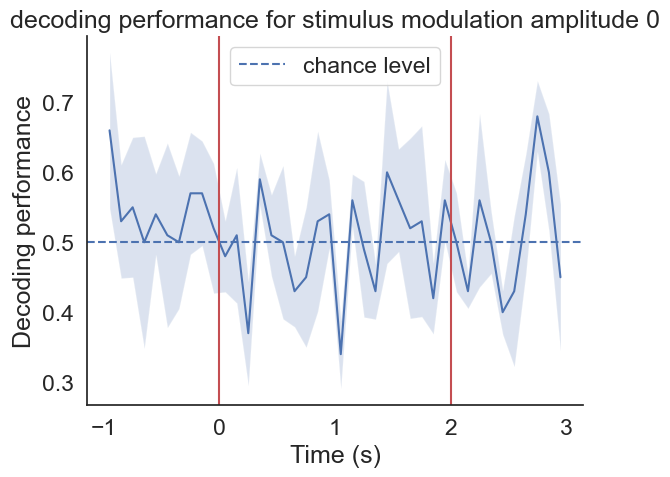

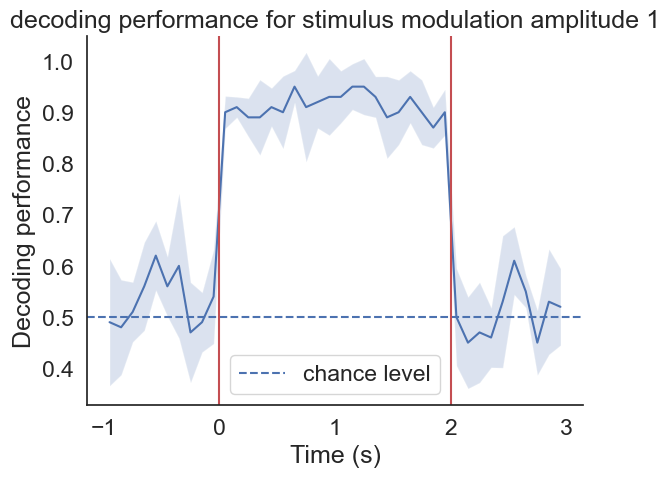

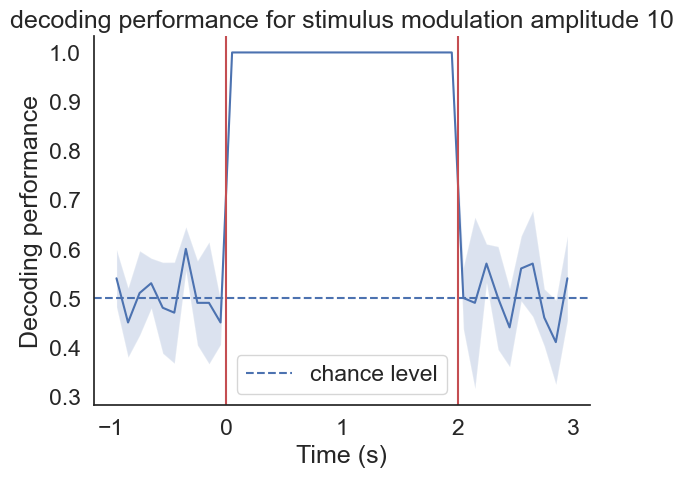

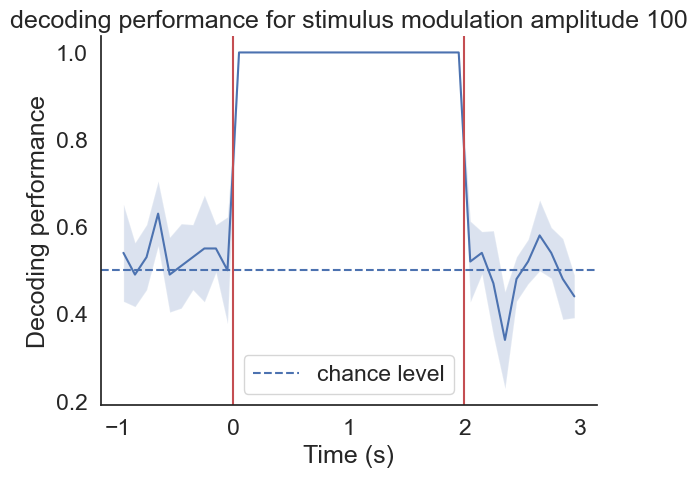

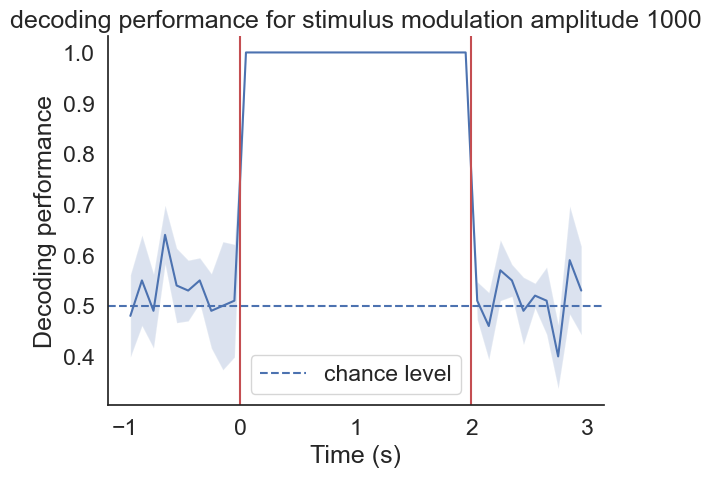

In [137]:
sigmas = [0,1,10,100,1000]

for sigma in sigmas:
    print(f"Now assessing decoding performance for stimulus modulation amplitude {sigma}")
    n_cells = 20; # number of cells to simulate
    n_stim_type = 2; # number of different stimuli
    sigma_stim = sigma # amplitude of stimulus related modulation
    average_firing_rate = 5; # average firing rate across the population

    # generate baseline rates from exponential distirbution
    cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

    # create stimulus average responses, perturbing the population firng rate profile
    # we use a multiplicative modulation in opposite directions for the two stimuli
    modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
    cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
    # sets negative firng rate to 0
    cell_rate_stim[1][cell_rate_stim[1]<0]=0
    cell_rate_stim[2][cell_rate_stim[2]<0]=0

    # simulate spiking activity

    s_rate = 10000 # the sampling rate of our emulated recording system
    noise_rate = 1 # we are going to add some spike noise non related to the task
    n_stim = 100 # number of stimuli

    stim_dur = 2 #stimulus duration (in seconds)
    is_interval = 3 # interval between stimuli  (in seconds)

    stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
    stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
    np.random.shuffle(stim_type)

    time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

    spike_times = []
    for cell in range(n_cells):
        ## Modified these lines slightly so that noise is actually added to the firing rate
        spikes = np.random.poisson((cell_rate_baseline[cell] + noise_rate) / s_rate,size=time.shape)

        for i, stimulus in enumerate(stim_type):
            stim_idxs = np.arange(stim_onsets[i]*s_rate, (stim_onsets[i]+stim_dur)*s_rate)
            spikes[stim_idxs] = np.random.poisson((cell_rate_stim[stimulus][cell] + noise_rate) / s_rate,size=stim_idxs.shape) 


        spike_times.append(time[spikes>0])

    # save ouput
    out_dict = {'spike_times':spike_times,
                'stim_onsets':stim_onsets,
                'stim_type':stim_type,
                'stim_duration':stim_dur
                }

    with open('data/simulated_data1.pickle', 'wb') as handle:
        pickle.dump(out_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # import data
    with open('data/simulated_data1.pickle', 'rb') as handle:
        data = pickle.load(handle)

    spike_times = data['spike_times']
    stim_onsets = data['stim_onsets']
    stim_type = data['stim_type']
    stim_duration = data['stim_duration']


    ## Here the performance assessment and plotting starts


    onset = 1 # in seconds before stimulus onset
    offset = 1 # in second after stimulus offset

    binwidth = 0.1 # in seconds (100 ms)
    bins = np.arange(-onset,stim_duration+offset+binwidth,binwidth)

    n_cells = len(spike_times)
    n_trials= len(stim_type)

    X = np.zeros((n_cells,n_trials,len(bins)-1));
    for cell in range(n_cells):    
        for trial in range(n_trials):

            # selects spikes that are in trial
            sp_idx = np.logical_and(spike_times[cell]>stim_onsets[trial]-onset,
                    spike_times[cell]<stim_onsets[trial]+stim_duration+offset)
            
            # centers spike times around stimulus onset
            sp_cntr = spike_times[cell][sp_idx]-stim_onsets[trial]
            #bins spikes
            spike_count,_ = np.histogram(sp_cntr,bins)
            #spike_count = zscore(spike_count)
            X[cell,trial,:] = spike_count

    ## The code below is what the lesson used for plotting the activity of a cell w.r.t. stimulus presentations, use if results are confusing
    # neuron = 5
    # plt.figure(figsize=(10,5))
    # plt.subplot(1,2,1)
    # plt.title('Sound A')
    # sns.heatmap(X[neuron][stim_type==1],cmap=plt.cm.jet)
    # plt.axvline(x=10,c='r',linewidth=3)
    # plt.axvline(x=30,c='r',linewidth=3)
    # plt.xlabel('time bin')
    # plt.ylabel('stimulus presentation')

    # plt.subplot(1,2,2)
    # plt.title('Sound B')
    # sns.heatmap(X[neuron][stim_type==2],cmap=plt.cm.jet)
    # plt.axvline(x=10,c='r',linewidth=3)
    # plt.axvline(x=30,c='r',linewidth=3)
    # plt.xlabel('time bin')
    # plt.ylabel('stimulus presentation')

    # plt.tight_layout()

    n_splits = 5

    avg_performance = []
    std_performance = []

    for time_bin in range(X.shape[-1]):
            # setting 2-fold cross validation
            kf = StratifiedKFold(n_splits=n_splits,shuffle=True)
            fold_performance = []

            for train_index, test_index in kf.split(X[:,:,time_bin].T,stim_type):
                    

                    X_train, X_test = X[:,train_index,time_bin].T, X[:,test_index,time_bin].T
                    y_train, y_test = stim_type[train_index], stim_type[test_index]

                    clf = svm.LinearSVC(max_iter=1000)
                    clf.fit(X_train, y_train)
                    fold_performance.append(clf.score(X_test,y_test))

            avg_performance.append(np.mean(fold_performance))
            std_performance.append(np.std(fold_performance))

    avg_performance = np.asarray(avg_performance)
    std_performance = np.asarray(std_performance)


    bin_centers = [(bins[i+1]+bins[i])/2 for i in range(len(bins)-1)]
    plt.figure()
    plt.plot(bin_centers,avg_performance)
    plt.title(f"decoding performance for stimulus modulation amplitude {sigma}")
    plt.fill_between(bin_centers,avg_performance-std_performance,
                    avg_performance+std_performance,alpha=0.2)

    plt.axhline(y=0.5,linestyle='--',label='chance level')
    plt.axvline(x=0,c='r')
    plt.axvline(x=2,c='r')

    plt.legend()
    plt.xlabel('Time (s)')
    plt.ylabel('Decoding performance')





Predictably, as one increases stimulus modulation amplitude decoding becomes more accurate as well, since this makes the firing activity of the cells easier to distinguish from noise. The two effects above reflect how signal to noise ratio affect decoding performance.

Now assessing decoding performance for 1 cells
Now assessing decoding performance for 10 cells
Now assessing decoding performance for 20 cells
Now assessing decoding performance for 30 cells
Now assessing decoding performance for 40 cells
Now assessing decoding performance for 50 cells


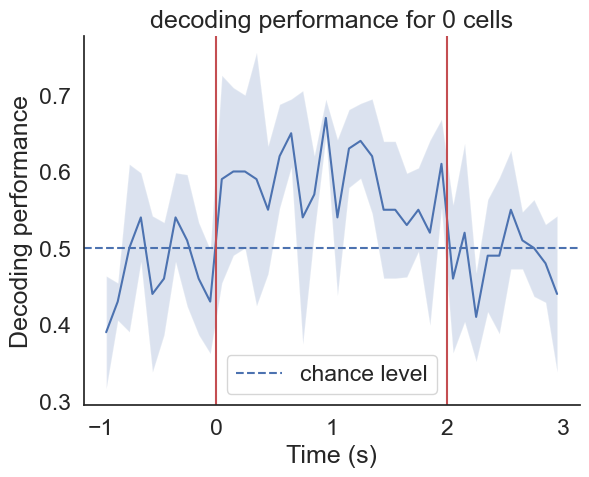

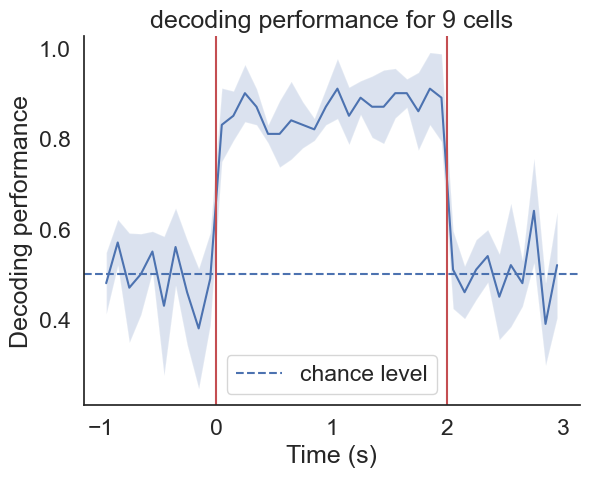

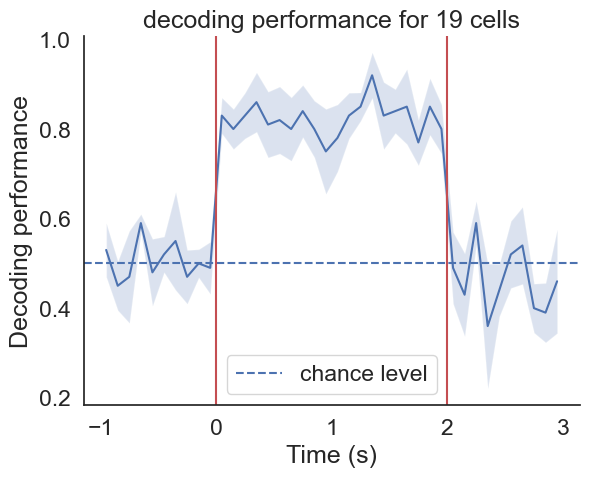

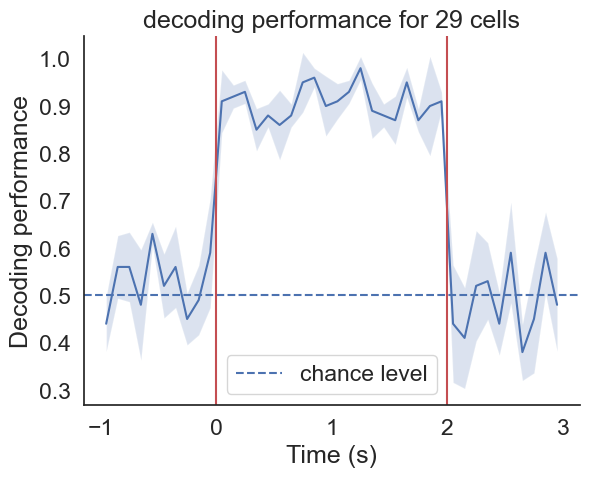

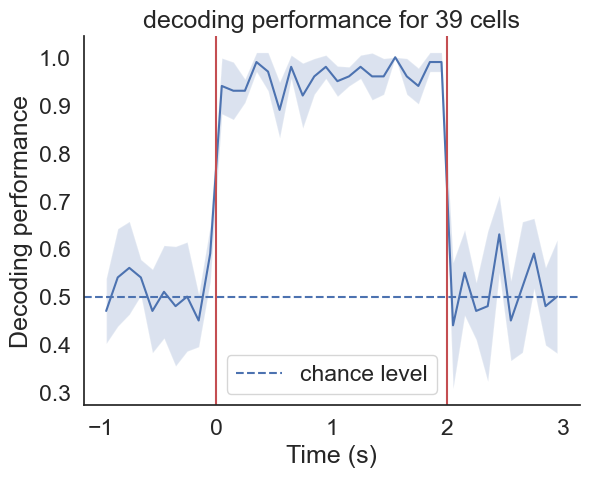

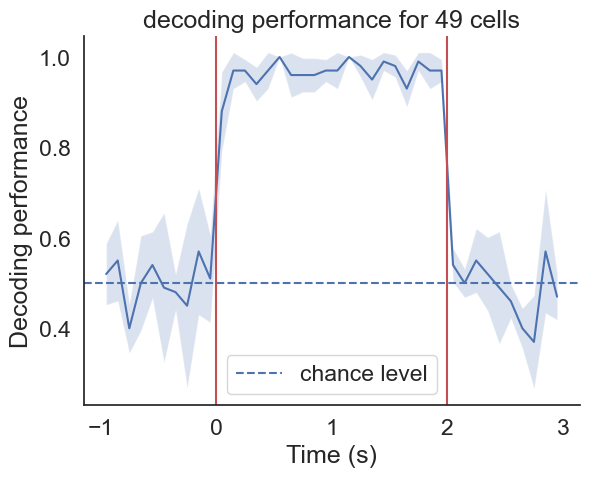

In [139]:
cells = [1,10,20,30,40,50]

for cell in cells:
    print(f"Now assessing decoding performance for {cell} cells")
    n_cells = cell; # number of cells to simulate
    n_stim_type = 2; # number of different stimuli
    sigma_stim = 0.5 # amplitude of stimulus related modulation
    average_firing_rate = 5; # average firing rate across the population

    # generate baseline rates from exponential distirbution
    cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

    # create stimulus average responses, perturbing the population firng rate profile
    # we use a multiplicative modulation in opposite directions for the two stimuli
    modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
    cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
    # sets negative firng rate to 0
    cell_rate_stim[1][cell_rate_stim[1]<0]=0
    cell_rate_stim[2][cell_rate_stim[2]<0]=0

    # simulate spiking activity

    s_rate = 10000 # the sampling rate of our emulated recording system
    noise_rate = 1 # we are going to add some spike noise non related to the task
    n_stim = 100 # number of stimuli

    stim_dur = 2 #stimulus duration (in seconds)
    is_interval = 3 # interval between stimuli  (in seconds)

    stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
    stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
    np.random.shuffle(stim_type)

    time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

    spike_times = []
    for cell in range(n_cells):
        ## Modified these lines slightly so that noise is actually added to the firing rate
        spikes = np.random.poisson((cell_rate_baseline[cell] + noise_rate) / s_rate,size=time.shape)

        for i, stimulus in enumerate(stim_type):
            stim_idxs = np.arange(stim_onsets[i]*s_rate, (stim_onsets[i]+stim_dur)*s_rate)
            spikes[stim_idxs] = np.random.poisson((cell_rate_stim[stimulus][cell] + noise_rate) / s_rate,size=stim_idxs.shape) 


        spike_times.append(time[spikes>0])

    # save ouput
    out_dict = {'spike_times':spike_times,
                'stim_onsets':stim_onsets,
                'stim_type':stim_type,
                'stim_duration':stim_dur
                }

    with open('data/simulated_data1.pickle', 'wb') as handle:
        pickle.dump(out_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # import data
    with open('data/simulated_data1.pickle', 'rb') as handle:
        data = pickle.load(handle)

    spike_times = data['spike_times']
    stim_onsets = data['stim_onsets']
    stim_type = data['stim_type']
    stim_duration = data['stim_duration']


    ## Here the performance assessment and plotting starts


    onset = 1 # in seconds before stimulus onset
    offset = 1 # in second after stimulus offset

    binwidth = 0.1 # in seconds (100 ms)
    bins = np.arange(-onset,stim_duration+offset+binwidth,binwidth)

    n_cells = len(spike_times)
    n_trials= len(stim_type)

    X = np.zeros((n_cells,n_trials,len(bins)-1));
    for cell in range(n_cells):    
        for trial in range(n_trials):

            # selects spikes that are in trial
            sp_idx = np.logical_and(spike_times[cell]>stim_onsets[trial]-onset,
                    spike_times[cell]<stim_onsets[trial]+stim_duration+offset)
            
            # centers spike times around stimulus onset
            sp_cntr = spike_times[cell][sp_idx]-stim_onsets[trial]
            #bins spikes
            spike_count,_ = np.histogram(sp_cntr,bins)
            #spike_count = zscore(spike_count)
            X[cell,trial,:] = spike_count

    ## The code below is what the lesson used for plotting the activity of a cell w.r.t. stimulus presentations, use if results are confusing
    # neuron = 5
    # plt.figure(figsize=(10,5))
    # plt.subplot(1,2,1)
    # plt.title('Sound A')
    # sns.heatmap(X[neuron][stim_type==1],cmap=plt.cm.jet)
    # plt.axvline(x=10,c='r',linewidth=3)
    # plt.axvline(x=30,c='r',linewidth=3)
    # plt.xlabel('time bin')
    # plt.ylabel('stimulus presentation')

    # plt.subplot(1,2,2)
    # plt.title('Sound B')
    # sns.heatmap(X[neuron][stim_type==2],cmap=plt.cm.jet)
    # plt.axvline(x=10,c='r',linewidth=3)
    # plt.axvline(x=30,c='r',linewidth=3)
    # plt.xlabel('time bin')
    # plt.ylabel('stimulus presentation')

    # plt.tight_layout()

    n_splits = 5

    avg_performance = []
    std_performance = []

    for time_bin in range(X.shape[-1]):
            # setting 2-fold cross validation
            kf = StratifiedKFold(n_splits=n_splits,shuffle=True)
            fold_performance = []

            for train_index, test_index in kf.split(X[:,:,time_bin].T,stim_type):
                    

                    X_train, X_test = X[:,train_index,time_bin].T, X[:,test_index,time_bin].T
                    y_train, y_test = stim_type[train_index], stim_type[test_index]

                    clf = svm.LinearSVC(max_iter=1000)
                    clf.fit(X_train, y_train)
                    fold_performance.append(clf.score(X_test,y_test))

            avg_performance.append(np.mean(fold_performance))
            std_performance.append(np.std(fold_performance))

    avg_performance = np.asarray(avg_performance)
    std_performance = np.asarray(std_performance)


    bin_centers = [(bins[i+1]+bins[i])/2 for i in range(len(bins)-1)]
    plt.figure()
    plt.plot(bin_centers,avg_performance)
    plt.title(f"decoding performance for {cell} cells")
    plt.fill_between(bin_centers,avg_performance-std_performance,
                    avg_performance+std_performance,alpha=0.2)

    plt.axhline(y=0.5,linestyle='--',label='chance level')
    plt.axvline(x=0,c='r')
    plt.axvline(x=2,c='r')

    plt.legend()
    plt.xlabel('Time (s)')
    plt.ylabel('Decoding performance')





Decoding performance increases if the population of cells that are analysed grows. This makes sense because it can be expected that increasing the amount of cells that can encode information makes it easier to aggregate patterns and ascertain from overall activity more subtle differences and similarities. Performance increases mainly because sample size has increased